In [15]:
dataset = 'kitti'

In [16]:
from pathlib import Path
import glob 
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

att_type = 'Random'
att_type_ext = '_dataset.att_mode=random' # for random

att_type = 'Constant'
att_type_ext = '_dataset.att_mode=constant'
att_type_ext = ''

result_total = pd.DataFrame()
columns = ['EvalType', 'APType', 'Easy', 'Moderate', 'Hard']
plot_dir = Path(f"../artifacts/plots/{dataset}/tracking/{att_type}/")
plot_dir.mkdir(exist_ok=True,parents=True)

In [17]:
result_total = pd.DataFrame()


for Delay_Camera in range(0, 6):
    for delay_lidar in range(0, 6):
        result_file_dir = Path(f'/home/hasan/workspace/MMF-JDT/output_dataset.delays.image={Delay_Camera}_dataset.delays.lidar={delay_lidar}{att_type_ext}/training/results/data/car_summary.txt')
        try:
            # df = pd.read_csv(result_file_dir, header=0, index_col=False)
            df = pd.read_csv(result_file_dir, header=0, index_col=False, sep=' ')
            df['Delay_Camera'] = Delay_Camera
            df['Delay_Lidar'] = delay_lidar
            print(f"File loaded: {result_file_dir}")
        except Exception as e:
            print(e)
            # print(f"File not found: {result_file_dir}")
            continue
        result_total = pd.concat([result_total, df], axis=0)
        print(result_total.shape)



# result_total = result_total.sort_values(by=['Delay_Camera', 'Delay_Lidar'])
# result_total[['Delay_Camera','Delay_Lidar']] = result_total[['Delay_Camera','Delay_Lidar']].astype(int)
# result_dir = Path("../artifacts/results/kitti_tracking_results_total.csv")
# result_dir.parent.mkdir(exist_ok=True,parents=True)
# result_total.to_csv(result_dir, header=True)

File loaded: /home/hasan/workspace/MMF-JDT/output_dataset.delays.image=0_dataset.delays.lidar=0/training/results/data/car_summary.txt
(1, 41)
File loaded: /home/hasan/workspace/MMF-JDT/output_dataset.delays.image=0_dataset.delays.lidar=1/training/results/data/car_summary.txt
(2, 41)
File loaded: /home/hasan/workspace/MMF-JDT/output_dataset.delays.image=0_dataset.delays.lidar=2/training/results/data/car_summary.txt
(3, 41)
File loaded: /home/hasan/workspace/MMF-JDT/output_dataset.delays.image=0_dataset.delays.lidar=3/training/results/data/car_summary.txt
(4, 41)
File loaded: /home/hasan/workspace/MMF-JDT/output_dataset.delays.image=0_dataset.delays.lidar=4/training/results/data/car_summary.txt
(5, 41)
File loaded: /home/hasan/workspace/MMF-JDT/output_dataset.delays.image=0_dataset.delays.lidar=5/training/results/data/car_summary.txt
(6, 41)
File loaded: /home/hasan/workspace/MMF-JDT/output_dataset.delays.image=1_dataset.delays.lidar=0/training/results/data/car_summary.txt
(7, 41)
File l

In [18]:
# eval_metrics = ['HOTA', 'DetA', 'AssA', 'DetRe', 'DetPr', 'AssRe', 'AssPr', 'LocA', 'MOTA']
eval_metrics = ['HOTA', 'DetA', 'AssA', 'MOTA', 'IDSW'] #'MOTP',

# HOTA (Higher Order Tracking Accuracy) : Balances detection, association, and localization for overall tracking performance.
# DetA (Detection Accuracy): Measures the correctness of both detecting objects and their spatial localization.
# AssA (Association Accuracy): Evaluates how well object identities are maintained across frames.
# DetRe (Detection Recall) : Measures the proportion of actual objects correctly detected.
# DetPr (Detection Precision) : Evaluates the accuracy of detected objects while minimizing false positives.
# AssRe (Association Recall) : Measures how many correct associations between objects are recovered.
# AssPr (Association Precision) : Evaluates the accuracy of predicted object associations across frames.
# LocA (Localization Accuracy) : Assesses how precisely detected objects align with their ground truth positions.
# MOTA (Multiple Object Tracking Accuracy) : Combines false positives, false negatives, and ID switches into a single tracking score.

In [19]:
import pandas as pd

# Reshape the DataFrame
df_melted = result_total.melt(
    id_vars=['Delay_Camera', 'Delay_Lidar'],
    value_vars= eval_metrics,
    var_name='Metric',
    value_name='Value'
)

print(df_melted)


     Delay_Camera  Delay_Lidar Metric   Value
0               0            0   HOTA  77.511
1               0            1   HOTA  76.825
2               0            2   HOTA  76.771
3               0            3   HOTA  77.148
4               0            4   HOTA  76.284
..            ...          ...    ...     ...
175             5            1   IDSW  91.000
176             5            2   IDSW  78.000
177             5            3   IDSW  55.000
178             5            4   IDSW  33.000
179             5            5   IDSW  10.000

[180 rows x 4 columns]


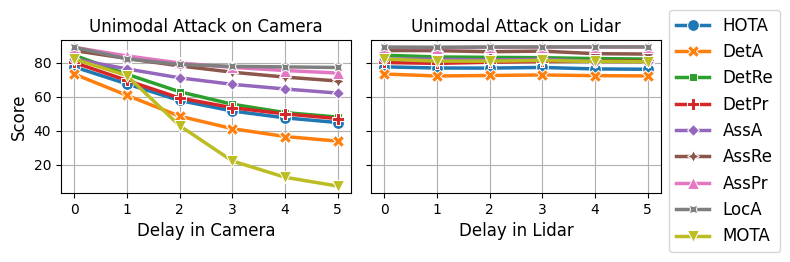

In [20]:
eval_metrics_full = ['HOTA', 'DetA', 'DetRe',  'DetPr', 'AssA',  'AssRe', 'AssPr', 'LocA', 'MOTA'] #, 'IDSW']

# Reshape the DataFrame
df_melted_complete = result_total.melt(
    id_vars=['Delay_Camera', 'Delay_Lidar'],
    value_vars= eval_metrics_full,
    var_name='Metric',
    value_name='Value'
)

fig, axes = plt.subplots(1, 2, figsize=(8, 2.75), sharex=True, sharey=True)
for ax, (tar_mod, safe_mod) in zip(axes, [['Delay_Camera', 'Delay_Lidar'], ['Delay_Lidar', 'Delay_Camera']]):
    
    df = df_melted_complete[df_melted_complete[safe_mod] == 0]
    sns.lineplot(
        data=df,
        x=tar_mod,
        y='Value',
        hue='Metric',
        style='Metric',
        hue_order=eval_metrics_full,      # <- Custom order here
        style_order=eval_metrics_full,    # <- Keep markers/styles consistent
        markers=True,
        dashes=False,
        linewidth=2.5,
        markersize=8.5,
        ax=ax
    )

    ax.set_xlabel(tar_mod.replace("_", " in "), fontsize=12)
    if ax == axes[0]:
        ax.set_ylabel("Score", fontsize=12)
        ax.legend().set_visible(False)
    else:
        ax.legend(bbox_to_anchor=(1, 1.25), fontsize=12)
    ax.grid(True)
    target_mod = tar_mod.split("_")[1].capitalize()
    ax.set_title(f"Unimodal Attack on {target_mod}", fontsize=12)
    ax.set_xticks([0,1,2,3,4,5])
plt.tight_layout()
fig_dir = plot_dir / f"attack_impact_line_{dataset}_hue_metrics"
fig.savefig(f"{fig_dir}"+".jpg", dpi=350)
fig.savefig(f"{fig_dir}"+".pdf", dpi=350)
plt.show()

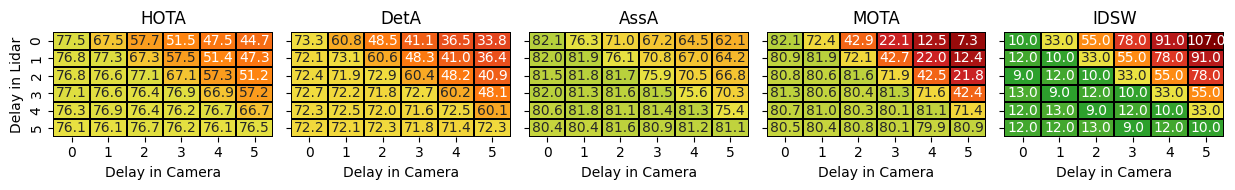

In [21]:
import matplotlib.colors as mcolors

fig, axes = plt.subplots(1, 5, figsize=(12.5, 2), sharex=True, sharey=True)
eval_metrics_full = ['HOTA', 'MOTA', 'IDSW']

for ax, metric in zip(axes.flatten(), eval_metrics):
    df_filtered = df_melted[df_melted['Metric'] == metric]

    df_pivot = df_filtered.pivot(index='Delay_Camera', columns='Delay_Lidar', values='Value')

    if metric in ['IDSW']:
        vmin = df_filtered['Value'].min()
        vmax = df_filtered['Value'].max()
            # Custom colormap with multiple color transitions
        colors = ["#2ca02c", "#f0e442", "#ff7f0e", "#d62728", "#800000"]  # Green → Yellow → Orange → Red → Dark Red 
    else:
        vmin = 0
        vmax = 100
        colors = ["#2ca02c", "#f0e442", "#ff7f0e", "#d62728", "#800000"][::-1]  # Green → Yellow → Orange → Red → Dark Red 

    cmap = mcolors.LinearSegmentedColormap.from_list("CustomGreenRed", colors, N=256)

    ax.set_title(f"{metric}")
    sns.heatmap(df_pivot.T, fmt='0.1f', annot=True, cmap=cmap, linewidths=0.10, linecolor='black', cbar=False, vmin=vmin, vmax=vmax,ax=ax) #vmin=vmin, vmax=vmax,

    if ax in [axes[0]]:
        ax.set_ylabel("Delay in Lidar")
    else:
        ax.set_ylabel("")

    ax.set_xlabel("Delay in Camera")
    
plt.tight_layout()
fig_dir = plot_dir / f"attack_impact_grid_{dataset}_all_class"
fig.savefig(f"{fig_dir}"+".jpg", dpi=350)
fig.savefig(f"{fig_dir}"+".pdf", dpi=350)
plt.show()


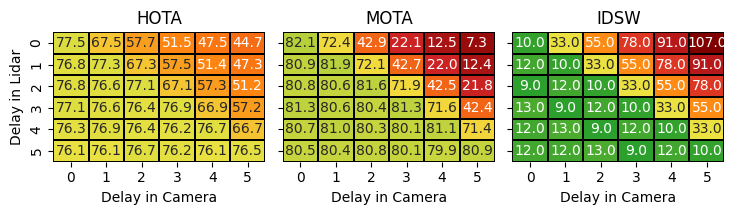

In [22]:
import matplotlib.colors as mcolors
eval_metrics = ['HOTA', 'MOTA', 'IDSW']

# fig, axes = plt.subplots(1, 5, figsize=(12.5, 2), sharex=True, sharey=True)
fig, axes = plt.subplots(1, 3, figsize=(7.5, 2.25), sharex=True, sharey=True)

for ax, metric in zip(axes.flatten(), eval_metrics):
    df_filtered = df_melted[df_melted['Metric'] == metric]

    df_pivot = df_filtered.pivot(index='Delay_Camera', columns='Delay_Lidar', values='Value')

    if metric in ['IDSW']:
        vmin = df_filtered['Value'].min()
        vmax = df_filtered['Value'].max()
            # Custom colormap with multiple color transitions
        colors = ["#2ca02c", "#f0e442", "#ff7f0e", "#d62728", "#800000"]  # Green → Yellow → Orange → Red → Dark Red 
    else:
        vmin = 0
        vmax = 100
        colors = ["#2ca02c", "#f0e442", "#ff7f0e", "#d62728", "#800000"][::-1]  # Green → Yellow → Orange → Red → Dark Red 

    cmap = mcolors.LinearSegmentedColormap.from_list("CustomGreenRed", colors, N=256)

    ax.set_title(f"{metric}")
    sns.heatmap(df_pivot.T, fmt='0.1f', annot=True, cmap=cmap, linewidths=0.10, linecolor='black', cbar=False, vmin=vmin, vmax=vmax,ax=ax) #vmin=vmin, vmax=vmax,

    if ax in [axes[0]]:
        ax.set_ylabel("Delay in Lidar")
    else:
        ax.set_ylabel("")

    ax.set_xlabel("Delay in Camera")
    
plt.tight_layout()
fig_dir = plot_dir / f"attack_impact_grid_{dataset}_three_class"
fig.savefig(f"{fig_dir}"+".jpg", dpi=350)
fig.savefig(f"{fig_dir}"+".pdf", dpi=350)
plt.show()


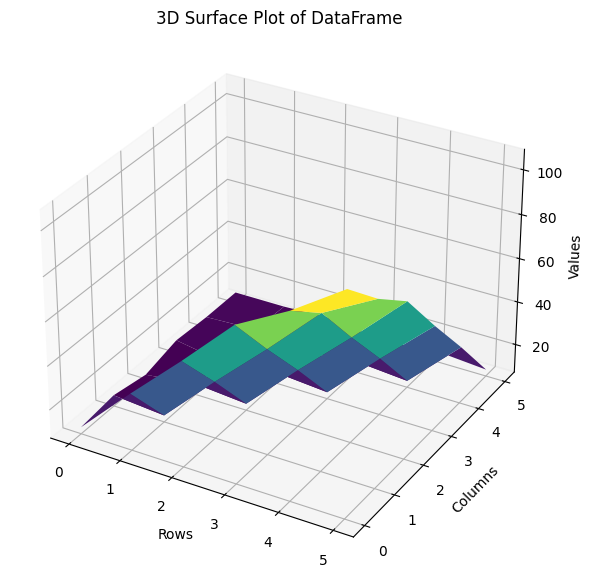

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# # Sample 5x5 DataFrame
# data = np.random.rand(5, 5)
# df = pd.DataFrame(data, columns=[f'Col {i+1}' for i in range(5)], index=[f'Row {i+1}' for i in range(5)])

df = df_pivot

# Create 3D surface plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Create meshgrid
x, y = np.meshgrid(np.arange(df.shape[0]), np.arange(df.shape[1]))

# Plot surface
ax.plot_surface(x, y, df.values.T, cmap='viridis')

ax.set_xlabel('Rows')
ax.set_ylabel('Columns')
ax.set_zlabel('Values')
plt.title('3D Surface Plot of DataFrame')
plt.show()


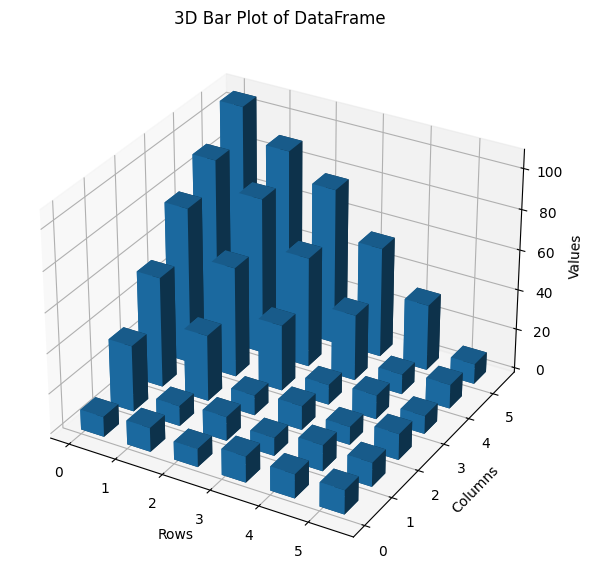

In [24]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Create meshgrid for bar plot
x, y = np.meshgrid(np.arange(df.shape[0]), np.arange(df.shape[1]))
x = x.flatten()
y = y.flatten()
z = np.zeros_like(x)
dx = dy = 0.5
dz = df.values.flatten()

# Plot bars
ax.bar3d(x, y, z, dx, dy, dz, shade=True, cmap='plasma')

ax.set_xlabel('Rows')
ax.set_ylabel('Columns')
ax.set_zlabel('Values')
plt.title('3D Bar Plot of DataFrame')
plt.show()
